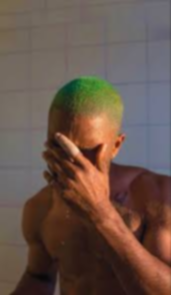

In [29]:
using Images
using ImageFiltering
using ImageEdgeDetection

image = load("./assets/download.jpeg")

# https://en.wikipedia.org/wiki/Normal_distribution

blurred = imfilter(image, Kernel.gaussian(1))

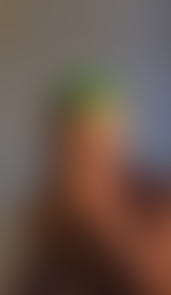

In [30]:
blurred = imfilter(image, Kernel.gaussian(20))

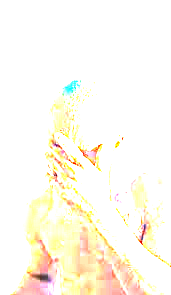

In [31]:
# sharpen edges Kernel
kernel = centered([
    -0.5 1.0 -0.5
    1.0 7.0 1.0
    -0.5 1.0 -0.5
])

img_float = RGB{Float32}.(image)
distinctEdges = imfilter(img_float, reflect(kernel))


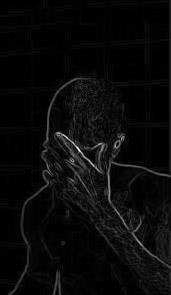

In [32]:
sy, sx = Kernel.sobel()
grad_x = imfilter(image, sx)
grad_y = imfilter(image, sy)
edgeImage = hypot.(grad_x, grad_y)

edge_norm = edgeImage ./ maximum(edgeImage)
Gray.(edge_norm)

# edgedImage = detect_edges(image, sobel())

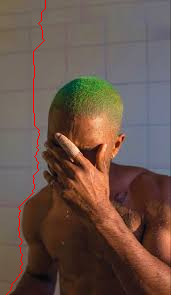

In [36]:
# https://en.wikipedia.org/wiki/Seam_carving

function edgeImageFunc(image)
    sy, sx = Kernel.sobel()
    grad_x = imfilter(image, sx)
    grad_y = imfilter(image, sy)
    edgeImage = hypot.(grad_x, grad_y)

    edge_norm = edgeImage ./ maximum(edgeImage)
    return Gray.(edge_norm)
end

function seamPixels(img)
    edgedOutImage = edgeImageFunc(img)

    (height, width) = size(edgedOutImage)

    energyImage = copy(edgedOutImage)

    for x in height:-1:1
        for y in width:-1:1
            if x == height
                energyImage[x, y] = edgedOutImage[x, y]
                continue
            end

            y_bottom = y
            y_bottom_left = clamp(y - 1, 1, width)
            y_bottom_right = clamp(y + 1, 1, width)

            leastArr = [edgedOutImage[(x+1), y_bottom] + edgedOutImage[x, y], edgedOutImage[(x+1), y_bottom] + edgedOutImage[x, y], edgedOutImage[(x+1), y_bottom] + edgedOutImage[x, y]]
            sort!(leastArr)

            energyImage[x, y] = leastArr[1]
        end
    end
    return energyImage
end

function traceSeamPixels(originalImage, energizedImage)
    (height, width) = size(energizedImage)
    
    tracedImage = RGB.(originalImage)
    
    _, minIndex = findmin(energizedImage[1, :])
    current_col = minIndex[1]

    for x in 1:height
        tracedImage[x, current_col] = RGB(1, 0, 0)
        
        if x == height
            break
        end
        
        c_left  = clamp(current_col - 1, 1, width)
        c_mid   = current_col
        c_right = clamp(current_col + 1, 1, width)
        
        e_left  = energizedImage[x + 1, c_left]
        e_mid   = energizedImage[x + 1, c_mid]
        e_right = energizedImage[x + 1, c_right]
        
        if e_left <= e_mid && e_left <= e_right
            current_col = c_left
        elseif e_mid <= e_left && e_mid <= e_right
            current_col = c_mid
        else
            current_col = c_right
        end
    end
    
    return tracedImage
end

energyMap = seamPixels(image)
tracedSeamImage = traceSeamPixels(image, energyMap)